# SummaryPlot

`SummaryPlot` takes a DataFrame that already contains a model output column and shows how the values are distributed across threshold regions as a stacked bar. It does not evaluate any comfort model — you compute the output first (e.g., with `pmv_ppd_iso` or `utci`) and store it in the DataFrame, then hand the DataFrame to `SummaryPlot`.

This makes it a natural companion to `ThresholdPlot`: the threshold chart shows *where* in the input space conditions fall, and the summary bar shows *how often* they did.

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

from pythermalcomfort.models import pmv_ppd_iso, utci
from pythermalcomfort.plots.matplotlib import SummaryPlot, ThresholdPlot

## 1. Preparing a Measured Dataset

Start by computing the model output and storing it in the DataFrame. `SummaryPlot` only reads the output column — the other columns are ignored.

In [12]:
df = pd.DataFrame(
    {
        "tdb": [20.0, 22.0, 23.5, 24.5, 26.0, 27.5, 29.0, 20.0],
        "rh": [50.0, 45.0, 50.0, 50.0, 55.0, 60.0, 60.0, 65.0],
        "tr": [20.0, 21.5, 23.5, 24.5, 26.0, 28.0, 29.5, 20.0],
        "vr": [0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10],
        "met": [1.2, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2],
        "clo": [0.90, 0.80, 0.60, 0.50, 0.50, 0.40, 0.35, 0.80],
        "wme": [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    }
)

df["pmv"] = pmv_ppd_iso(
    tdb=df["tdb"],
    tr=df["tr"],
    vr=df["vr"],
    rh=df["rh"],
    met=df["met"],
    clo=df["clo"],
    wme=df["wme"],
).pmv

df.head(4)

,tdb,rh,tr,vr,met,clo,wme,pmv
0,20.0,50.0,20.0,0.1,1.2,0.9,0.0,-0.50
1,22.0,45.0,21.5,0.1,1.2,0.8,0.0,-0.28
2,23.5,50.0,23.5,0.1,1.2,0.6,0.0,-0.16
3,24.5,50.0,24.5,0.1,1.2,0.5,0.0,-0.06


## 2. Horizontal Bar (Default)

The default layout is a horizontal stacked bar. Each segment shows the share of measurements that fell in that region. Percentage labels appear inside segments that are wide enough to fit them; narrow segments are left unlabelled.

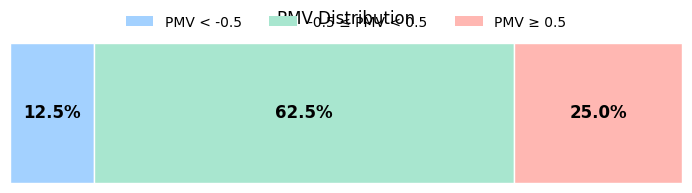

In [13]:
result = (
    SummaryPlot(df)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(title="PMV Distribution")
)
plt.show()

## 3. Vertical Bar

Pass `vertical=True` when the chart needs to fit into a narrow column — for example when placed next to a `ThresholdPlot` (see section 8).

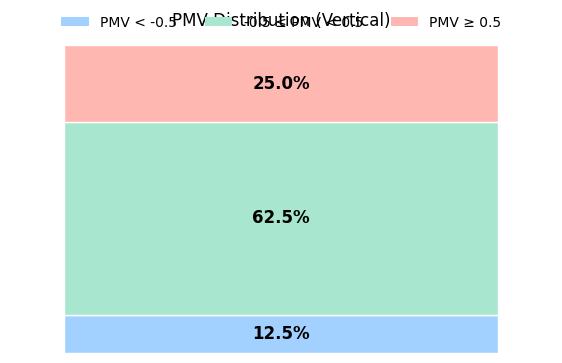

In [14]:
result_v = (
    SummaryPlot(df)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(vertical=True, title="PMV Distribution (Vertical)")
)
plt.show()

## 4. Custom Labels and Colors

Pass `labels` and `colors` to `set_regions` to override the auto-generated names and the default palette. Both lists must have length `len(thresholds) + 1`.

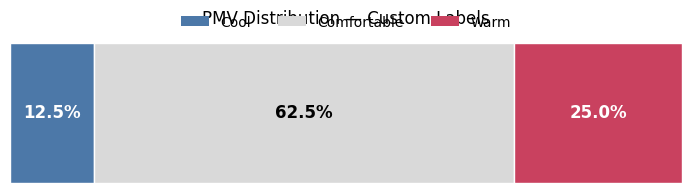

In [15]:
result_custom = (
    SummaryPlot(df)
    .set_regions(
        output="pmv",
        thresholds=[-0.5, 0.5],
        labels=["Cool", "Comfortable", "Warm"],
        colors=["#4c78a8", "#d9d9d9", "#c9415f"],
    )
    .plot(title="PMV Distribution — Custom Labels")
)
plt.show()

## 5. Hiding the Legend

Set `legend=False` to remove the colour key. Region labels are then rendered directly on the bar segments instead. This is useful when the chart is embedded alongside another plot that already carries the legend.

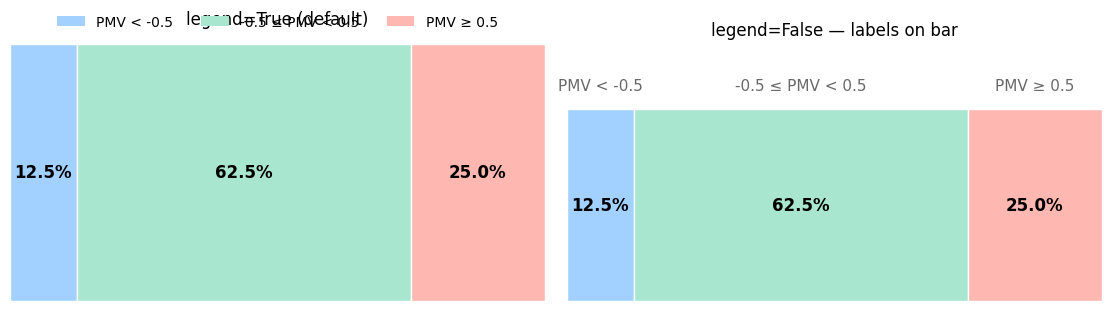

In [16]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 3), constrained_layout=True)

(
    SummaryPlot(df)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(ax=ax0, title="legend=True (default)")
)

(
    SummaryPlot(df)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(ax=ax1, title="legend=False — labels on bar", legend=False)
)

plt.show()

## 6. UTCI with Official Thermal Stress Labels

`SummaryPlot` works with any numeric output column. Here UTCI values are classified into three regions using the official UTCI thermal stress scale. A larger dataset is generated to make the distribution more meaningful.

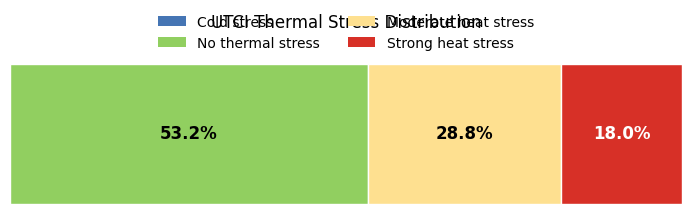

In [17]:
import numpy as np

rng = np.random.default_rng(7)
n = 120
df_utci = pd.DataFrame(
    {
        "tdb": rng.uniform(10, 38, n),
        "tr": rng.uniform(10, 42, n),
        "v": rng.uniform(0.2, 3.5, n),
        "rh": rng.uniform(20, 80, n),
    }
)
df_utci["utci"] = [
    utci(tdb=r.tdb, tr=r.tr, v=r.v, rh=r.rh).utci
    for r in df_utci.itertuples(index=False)
]
# Drop rows where UTCI is NaN — conditions outside the model's applicability
# limits. SummaryPlot requires all values in the output column to be finite.
df_utci = df_utci.dropna(subset=["utci"])

result_utci = (
    SummaryPlot(df_utci)
    .set_regions(
        output="utci",
        thresholds=[9, 26, 32],
        labels=[
            "Cold stress",
            "No thermal stress",
            "Moderate heat stress",
            "Strong heat stress",
        ],
        colors=["#4575b4", "#91cf60", "#fee090", "#d73027"],
    )
    .plot(title="UTCI Thermal Stress Distribution")
)
plt.show()

## 7. Reading `result.percentages`

`result.percentages` is a pandas `Series` indexed by region label. Use it to report compliance figures or pass values to other analyses.

In [18]:
print(result_utci.percentages)
print()

# Pick out a specific region
no_stress = result_utci.percentages["No thermal stress"]
print(f"Time with no thermal stress: {no_stress:.1f} %")

# Check compliance threshold
comfort_share = result_utci.percentages[["No thermal stress"]].sum()
print(f"Overall comfort compliance: {comfort_share:.1f} %")

Cold stress              0.0
No thermal stress       53.2
Moderate heat stress    28.8
Strong heat stress      18.0
Name: proportion, dtype: float64

Time with no thermal stress: 53.2 %
Overall comfort compliance: 53.2 %


## 8. Combined View: Comfort Zones + Time Distribution

Placing a `ThresholdPlot` and a `SummaryPlot` side by side answers two questions at once: *where* in the parameter space do conditions fall, and *what fraction of measurements landed in each region*. Use `labels=[]` on the `SummaryPlot` to suppress its own legend — the region colours already appear in the `ThresholdPlot` legend.

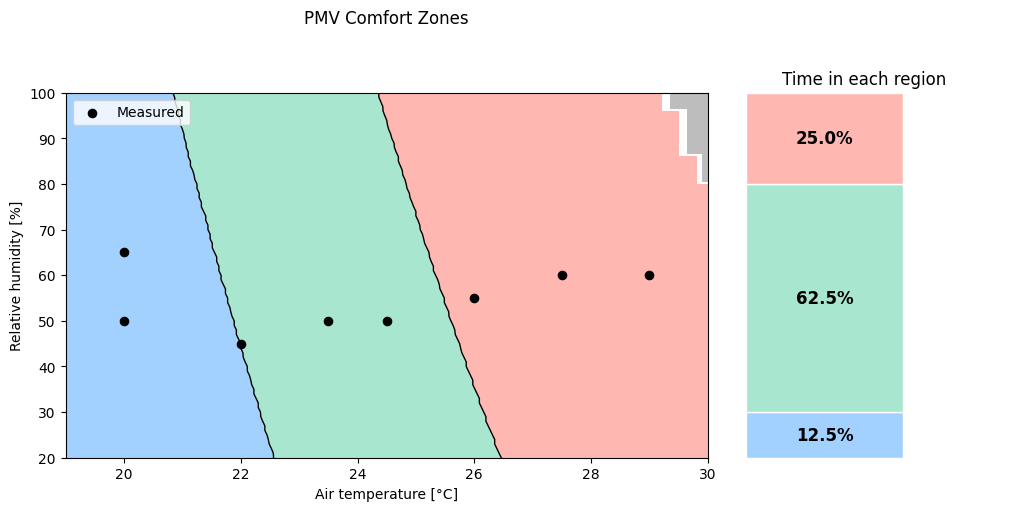

In [19]:
fig, (ax0, ax1) = plt.subplots(
    1,
    2,
    figsize=(10, 5),
    constrained_layout=True,
    gridspec_kw={"width_ratios": [2.8, 1.2]},
)

tp = (
    ThresholdPlot(pmv_ppd_iso)
    .set_x_axis("tdb", 19.0, 30.0, resolution=0.3)
    .set_y_axis("rh", 20.0, 100.0, resolution=1.0)
    .set_params(vr=0.10, met=1.2, clo=0.65, wme=0.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(ax=ax0, title="PMV Comfort Zones", legend_kws={"ncol": 3})
)
tp.ax.scatter(df["tdb"], df["rh"], color="black", s=35, zorder=5, label="Measured")
tp.ax.legend(loc="upper left")
tp.ax.set_xlabel("Air temperature [°C]")
tp.ax.set_ylabel("Relative humidity [%]")

(
    SummaryPlot(df)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5], labels=[])
    .plot(ax=ax1, vertical=True, title="Time in each region", legend=False)
)

plt.show()

## 9. Using `result.fig`

`result.fig` is the underlying `Figure`. Use it for figure-level operations such as adding a super-title or saving to disk.

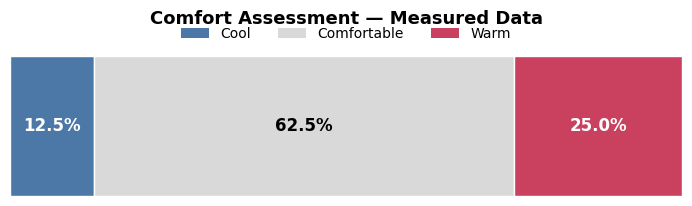

In [ ]:
r = (
    SummaryPlot(df)
    .set_regions(
        output="pmv",
        thresholds=[-0.5, 0.5],
        labels=["Cool", "Comfortable", "Warm"],
        colors=["#4c78a8", "#d9d9d9", "#c9415f"],
    )
    .plot() 
)

r.fig.suptitle(
    "Comfort Assessment — Measured Data", y=0.98, fontsize=13, fontweight="bold"
)
plt.show()